# MNIST Training & Visualization

This notebook trains the from-scratch CNN (`src/model.py`, built entirely
on the `Tensor` autograd engine from `src/engine.py`) on MNIST digit
classification, and visualizes the results — the CNN analogue of
[ann-foundation](https://github.com/rahulkp-ai/ann-foundation)'s
`Decision-Boundary-Visualization.ipynb`.

**Pipeline:** `Conv2D -> ReLU -> MaxPool2D -> Conv2D -> ReLU -> MaxPool2D -> Flatten -> Linear`,
trained with `Adam` and `cross_entropy` loss, evaluated with accuracy,
a confusion matrix, and a grid of sample predictions.

> **Note on data:** `utils.load_mnist()` downloads the standard MNIST
> files on first run. If no internet connection is available (e.g. a
> fully offline environment), it automatically falls back to a synthetic
> placeholder dataset of the same shape, so this notebook still runs
> end-to-end — just without meaningful digit-recognition accuracy. Swap
> in a real MNIST source any time internet access is available for
> genuine accuracy numbers.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.engine import Tensor
from src.layers import Conv2D, MaxPool2D, Flatten, Linear
from src.activations import relu
from src.model import CNN
from src.losses import cross_entropy, accuracy
from src.optim import Adam
from src.utils import (
    load_mnist, iterate_minibatches,
    plot_training_curve, plot_sample_predictions, plot_confusion_matrix,
)

np.random.seed(42)
# %matplotlib inline

## 2. Load MNIST

In [2]:
train_X, train_y, test_X, test_y = load_mnist(data_dir='./mnist_data')

print('train_X shape:', train_X.shape, ' (N, channels, height, width)')
print('train_y shape:', train_y.shape)
print('test_X shape: ', test_X.shape)
print('pixel value range:', train_X.min(), '-', train_X.max(), ' (normalized to [0, 1])')
print('class distribution (train):', np.bincount(train_y))

train_X shape: (60000, 1, 28, 28)  (N, channels, height, width)
train_y shape: (60000,)
test_X shape:  (10000, 1, 28, 28)
pixel value range: 0.0 - 1.0  (normalized to [0, 1])
class distribution (train): [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


Let's look at a few raw samples before training anything:

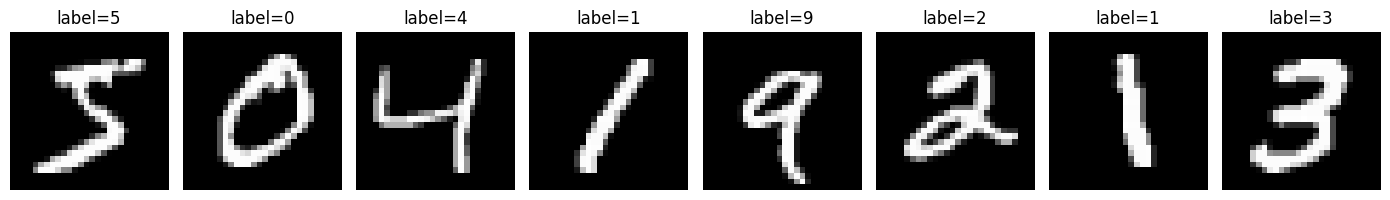

In [5]:
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(train_X[i, 0], cmap='gray')
    ax.set_title(f'label={train_y[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Build the CNN

Architecture: two conv blocks (each `Conv2D -> ReLU -> MaxPool2D`), then a
flatten and a single linear classifier head. `pad=1` with a 3x3 kernel
keeps spatial dimensions unchanged through each conv, so each `MaxPool2D`
is solely responsible for the 28 -> 14 -> 7 downsampling.

In [6]:
model = CNN(
    Conv2D(in_channels=1, out_channels=8, kernel_size=3, pad=1), relu,
    MaxPool2D(pool_size=2),                                          # 28x28 -> 14x14
    Conv2D(in_channels=8, out_channels=16, kernel_size=3, pad=1), relu,
    MaxPool2D(pool_size=2),                                          # 14x14 -> 7x7
    Flatten(),
    Linear(in_features=16 * 7 * 7, out_features=10),
)

print(model)
n_params = sum(p.data.size for p in model.parameters())
print(f'\nTotal trainable parameters: {n_params:,}')

Sequential(
  Conv2D(weight=(8, 1, 3, 3), stride=1, pad=1)
  <function relu at 0x11076a280>
  MaxPool2D(pool_size=2, stride=2)
  Conv2D(weight=(16, 8, 3, 3), stride=1, pad=1)
  <function relu at 0x11076a280>
  MaxPool2D(pool_size=2, stride=2)
  Flatten()
  Linear(in=784, out=10)
)

Total trainable parameters: 9,098


## 4. Training loop

A standard minibatch training loop: for each batch, zero gradients, forward
pass, compute loss, backward pass, optimizer step. This is the same
five-step pattern as ann-foundation's training loop, just operating over
minibatches instead of the full 4-point dataset at once (necessary once
data no longer fits comfortably in a single forward pass).

In [7]:
EPOCHS = 3
BATCH_SIZE = 64
LEARNING_RATE = 0.001

# Use a subset for a notebook-friendly runtime; increase for a full training run.
N_TRAIN = min(3000, train_X.shape[0])
N_TEST = min(500, test_X.shape[0])
X_train_sub, y_train_sub = train_X[:N_TRAIN], train_y[:N_TRAIN]
X_test_sub, y_test_sub = test_X[:N_TEST], test_y[:N_TEST]

optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):
    epoch_losses = []
    epoch_accs = []
    for xb, yb in iterate_minibatches(X_train_sub, y_train_sub, batch_size=BATCH_SIZE, shuffle=True, seed=epoch):
        optimizer.zero_grad()
        x = Tensor(xb)
        logits = model(x)
        loss = cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.data.item())
        epoch_accs.append(accuracy(logits, yb))
        train_losses.append(loss.data.item())
        train_accuracies.append(accuracy(logits, yb))

    print(f'Epoch {epoch+1}/{EPOCHS} | mean loss: {np.mean(epoch_losses):.4f} | mean train acc: {np.mean(epoch_accs):.3f}')

Epoch 1/3 | mean loss: 2.0141 | mean train acc: 0.438
Epoch 2/3 | mean loss: 0.8229 | mean train acc: 0.815
Epoch 3/3 | mean loss: 0.4315 | mean train acc: 0.875


## 5. Training curve

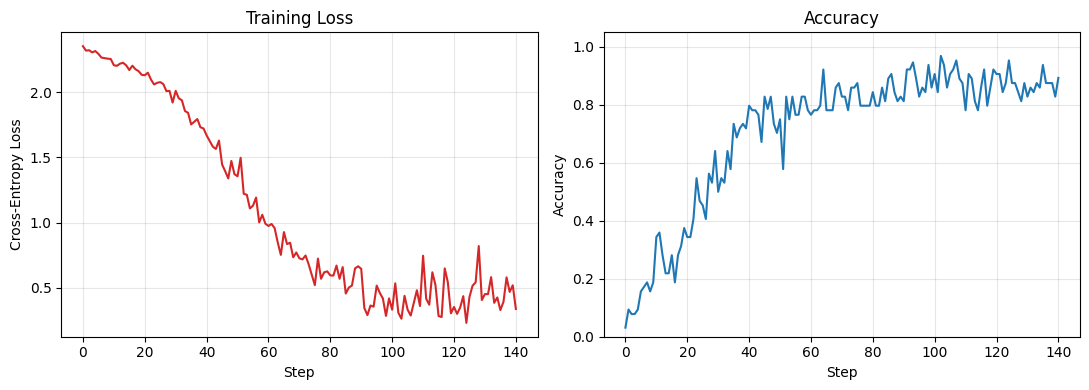

In [8]:
fig = plot_training_curve(train_losses, accuracies=train_accuracies)
plt.show()

## 6. Evaluation on the test set

In [9]:
x_test = Tensor(X_test_sub)
test_logits = model(x_test)
test_acc = accuracy(test_logits, y_test_sub)
test_preds = np.argmax(test_logits.data, axis=1)

print(f'Test accuracy on {N_TEST} held-out samples: {test_acc:.3f}')

Test accuracy on 500 held-out samples: 0.876


## 7. Sample predictions

Green title = correct prediction, red = incorrect. With the synthetic
fallback dataset this is mostly a pipeline sanity check; with real MNIST
data and more training, expect the vast majority to be green.

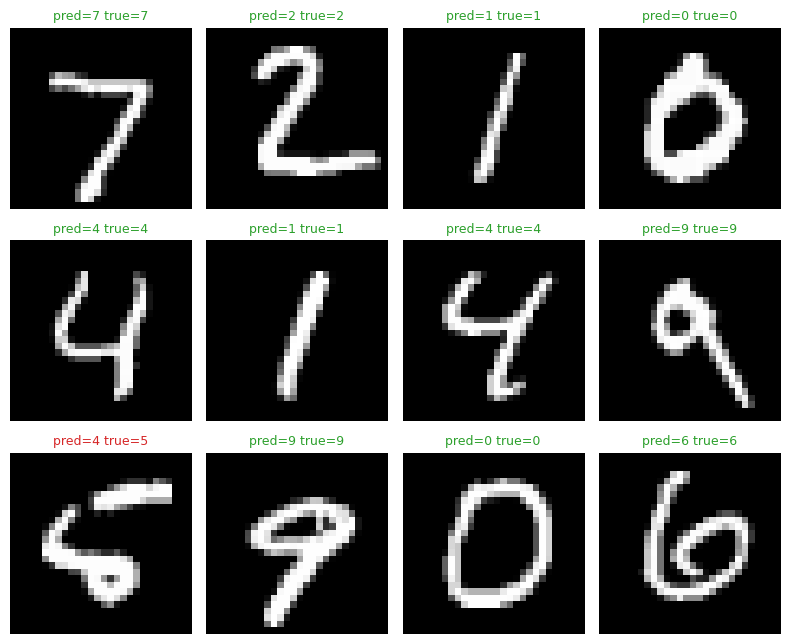

In [10]:
fig = plot_sample_predictions(X_test_sub, y_test_sub, test_preds, n=12)
plt.show()

## 8. Confusion matrix

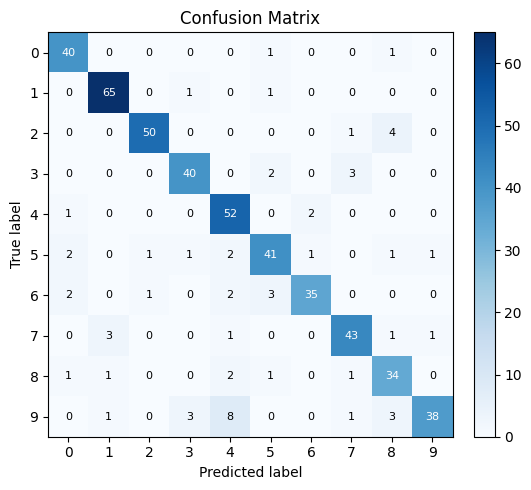

In [11]:
fig = plot_confusion_matrix(y_test_sub, test_preds, num_classes=10)
plt.show()

## Summary

This notebook trained the from-scratch `CNN` (built on a hand-written
`Tensor` autograd engine, `im2col`-based `conv2d`, and a from-scratch
`Adam` optimizer — no PyTorch, no TensorFlow) on MNIST, and visualized
training dynamics, sample predictions, and per-class errors.

For the underlying autograd mechanics (broadcasting, `im2col`, gradient
checks), see `notebooks/Tensor-Autograd.ipynb`. For the full numerical
gradient-verification test suite, see `tests/test_engine.py`,
`tests/test_layers.py`, and `tests/test_optim.py`.